# QEC Plot Notebook

This notebook is used to generate the main tables and figures for the paper from the simulation logs.

The four main experiment groups are:

1. Gate-fidelity sweep
   This compares `none`, `cec`, and `qec` while sweeping two-qubit gate fidelity, with one-qubit and measurement fidelity scaled accordingly. The goal is to identify the practical gate-fidelity threshold for each correction method.

2. Coherence-time sweep
   This compares `none`, `cec`, and `qec` while sweeping memory coherence time. The goal is to see how strongly each method depends on memory quality and where each approach begins to fail.

3. End-to-end distance sweep
   This keeps the elementary-link distance fixed at `10 km` and increases the total communication distance. The goal is to measure both latency and end-to-end fidelity as distance grows.

4. Link-count sweep
   This varies the number of links in the chain while keeping the elementary-link distance fixed at `10 km`. The goal is to study how end-to-end fidelity changes as the number of hops increases.


In [246]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


## Parse Logs

These regex patterns parse the log filenames and result lines.


In [247]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"(?:physbell=(?P<physbell>[0-9.]+|cfg),)?"
    r"ts=(?P<ts>\d{8}_\d{4})"
)

## Load Data

This function loads one log directory into a pandas dataframe.


In [248]:
def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue
        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue
                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "state_preparation_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": None if meta.get("physbell") in (None, "cfg") else float(meta["physbell"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                })
    return pd.DataFrame(rows)


# Experiments


In [249]:
run_after = None


In [250]:
output_dir = Path("/Users/patange/Documents/Argonne/QEC/plot_pngs")
output_dir.mkdir(parents=True, exist_ok=True)


## Qubit Overhead Table

Show total qubit overhead as a function of correction mode, FT preparation mode, and the number of nodes `n`.


In [251]:
n = 11  # Number of nodes in the linear chain.

qec_ancillas_by_mode = {"none": 0, "cec": 0, "qec": 3}
ft_ancillas_by_mode = {"none": 0, "minimal": 1, "standard": 4}

rows = []
for correction_mode, qec_ancillas in qec_ancillas_by_mode.items():
    for ft_prep_mode, ft_ancillas in ft_ancillas_by_mode.items():
        ancillas_per_end = max(qec_ancillas, ft_ancillas)
        comm_qubits_per_end = 7
        data_qubits_per_end = 7
        qubits_per_end = comm_qubits_per_end + data_qubits_per_end + ancillas_per_end
        total_qubits = 2 * (n - 1) * qubits_per_end
        rows.append({
            "n": n,
            "correction_mode": correction_mode,
            "ft_prep_mode": ft_prep_mode,
            "comm_qubits_per_end": comm_qubits_per_end,
            "data_qubits_per_end": data_qubits_per_end,
            "reserved_ancillas_per_end": ancillas_per_end,
            "qubits_per_end": qubits_per_end,
            "total_qubits": total_qubits,
        })

pd.DataFrame(rows).sort_values(["correction_mode", "ft_prep_mode"]).reset_index(drop=True)


,n,correction_mode,ft_prep_mode,comm_qubits_per_end,data_qubits_per_end,reserved_ancillas_per_end,qubits_per_end,total_qubits
0,11,cec,minimal,7,7,1,15,300
1,11,cec,none,7,7,0,14,280
2,11,cec,standard,7,7,4,18,360
3,11,none,minimal,7,7,1,15,300
4,11,none,none,7,7,0,14,280
5,11,none,standard,7,7,4,18,360
6,11,qec,minimal,7,7,3,17,340
7,11,qec,none,7,7,3,17,340
8,11,qec,standard,7,7,4,18,360


## Graph 1: Gate-Fidelity Sweep

Plot end-to-end fidelity versus two-qubit gate fidelity for `none`, `cec`, and `qec`.


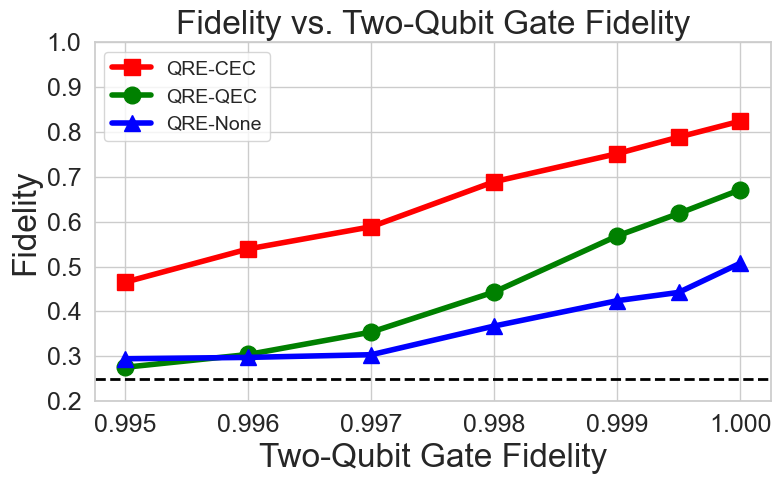

In [252]:
graph1_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph1_twoqubit_gate_sweep")
graph1_df = load_runner_logs(graph1_log_dir)

if graph1_df.empty:
    print("No Graph 1 data found.")
else:
    # Average all completed runs at each two-qubit fidelity and protocol setting.
    graph1_summary = graph1_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False).agg(mean_fidelity=("fidelity", "mean")).sort_values(["two_qubit_gate_fidelity", "correction_mode"]).reset_index(drop=True)
    # Keep the protocol colors and display names local to this plot.
    colors = {"cec": "red", "none": "blue", "qec": "green"}
    names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
    markers = {"cec": "s", "none": "^", "qec": "o"}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    # Draw each protocol separately so the marker shapes stay fixed.
    for protocol in ["cec", "qec", "none"]:
        data = graph1_summary[graph1_summary["correction_mode"] == protocol]
        ax.plot(data["two_qubit_gate_fidelity"], data["mean_fidelity"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
    ax.set_xlabel("Two-Qubit Gate Fidelity", fontsize=24)
    ax.set_ylabel("Fidelity", fontsize=24)
    ax.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=24)
    ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax.set_ylim(0.2, 1.0)
    ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.tick_params(axis="both", labelsize=18)
    ax.legend(fontsize=14, loc="upper left")
    plt.tight_layout()
    plt.savefig(output_dir / "fidelity_vs_two_qubit_gate_fidelity.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph1_summary


## Graph 2: Coherence-Time Sweep

Plot end-to-end fidelity versus coherence time for `none`, `cec`, and `qec`.


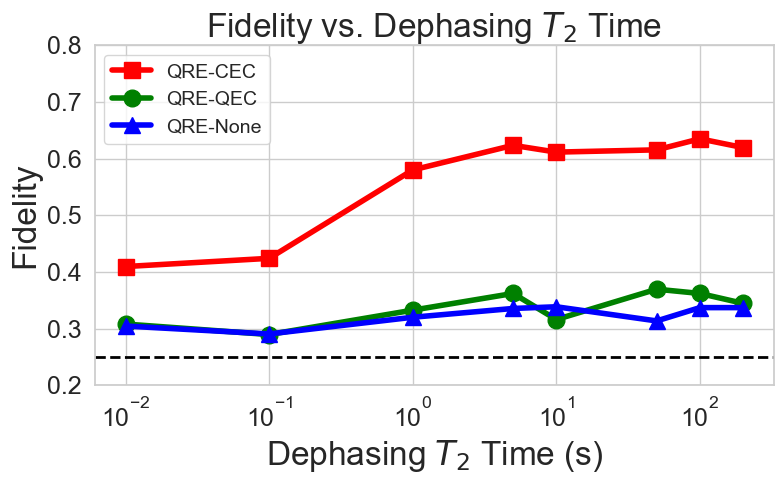

In [259]:
graph2_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph2_t2_sweep")
graph2_df = load_runner_logs(graph2_log_dir)


# Average all completed runs at each T2 value and protocol setting.
graph2_summary = graph2_df.groupby(["data_t2", "correction_mode"], as_index=False).agg(mean_fidelity=("fidelity", "mean")).sort_values(["data_t2", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()
# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph2_summary[graph2_summary["correction_mode"] == protocol]
    ax.plot(data["data_t2"], data["mean_fidelity"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
ax.set_xscale("log")
ax.set_xlabel("Dephasing $T_2$ Time (s)", fontsize=24)
ax.set_ylabel("Fidelity", fontsize=24)
ax.set_title("Fidelity vs. Dephasing $T_2$ Time", fontsize=24)
ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_ylim(0.2, 0.8)
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=14, loc="upper left")
plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_coherence_time.png", dpi=300, bbox_inches="tight")
plt.show()


## Graph 3: End-to-End Distance Sweep

Plot both latency and end-to-end fidelity versus total distance, with `10 km` elementary links.


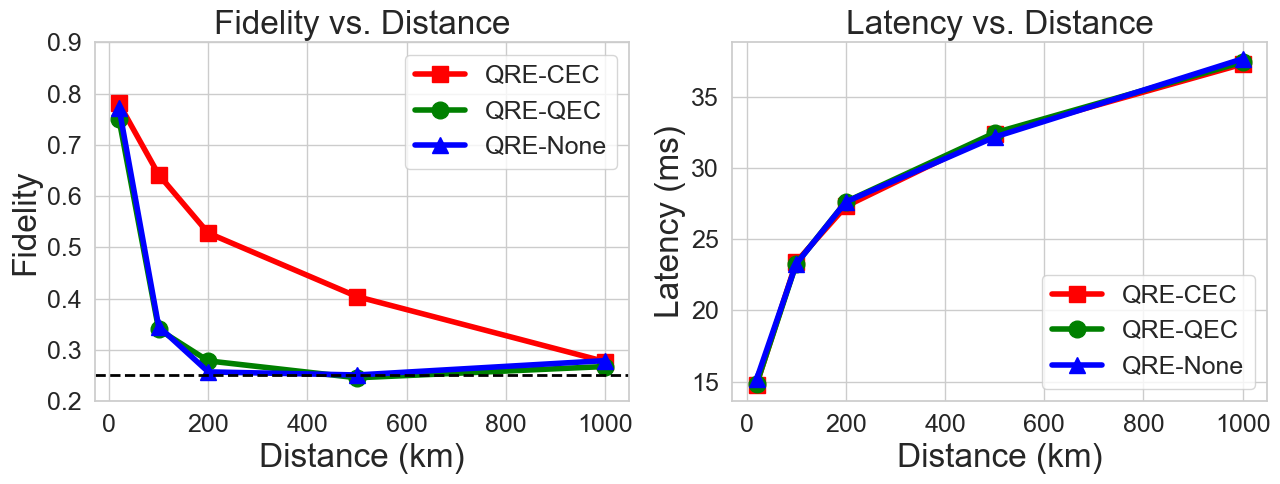

In [254]:
graph3_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph3_distance_sweep")
graph3_df = load_runner_logs(graph3_log_dir)


# Build one table with the mean latency and fidelity at each distance and protocol.
graph3_summary = graph3_df.groupby(["total_distance_km", "correction_mode"], as_index=False).agg(mean_fidelity=("fidelity", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["total_distance_km", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Left panel: latency.
ax0 = axes[1]
# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph3_summary[(graph3_summary["correction_mode"] == protocol) & (graph3_summary["total_distance_km"] != 2000)]
    ax0.plot(data["total_distance_km"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
ax0.set_xlabel("Distance (km)", fontsize=24)
ax0.set_ylabel("Latency (ms)", fontsize=24)
ax0.set_title("Latency vs. Distance", fontsize=24)
ax0.tick_params(axis="both", labelsize=18)

# Right panel: fidelity.
ax1 = axes[0]
for protocol in ["cec", "qec", "none"]:
    data = graph3_summary[(graph3_summary["correction_mode"] == protocol) & (graph3_summary["total_distance_km"] != 2000)]
    ax1.plot(data["total_distance_km"], data["mean_fidelity"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
ax1.set_xlabel("Distance (km)", fontsize=24)
ax1.set_ylabel("Fidelity", fontsize=24)
ax1.set_title("Fidelity vs. Distance", fontsize=24)
ax1.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax1.set_ylim(0.2, 0.9)
ax1.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ax1.tick_params(axis="both", labelsize=18)

ax0.legend(fontsize=18)
ax1.legend(fontsize=18)

plt.tight_layout()
plt.savefig(output_dir / "distance_sweep_varryingNodes.png", dpi=300, bbox_inches="tight")
plt.show()


## Graph 4: Link-Count Sweep

Plot end-to-end fidelity versus number of links, with `10 km` elementary links.


/var/folders/pz/qmtxblt536z17q2qg96mb3740000gn/T/ipykernel_58947/4176086033.py:40: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=0, top=5000)  # Set a minimum y-value to avoid issues with log scale.


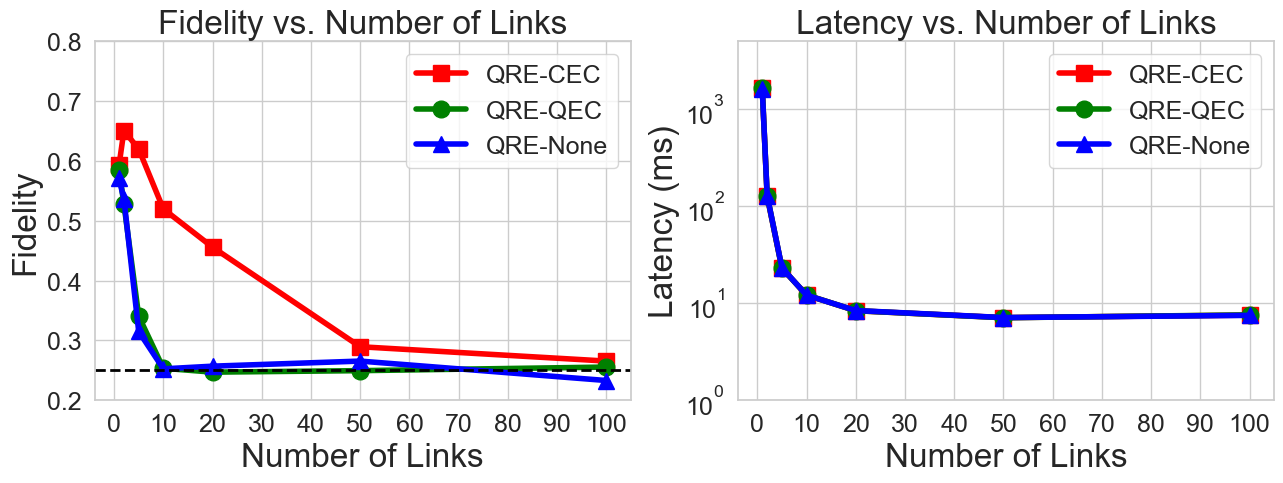

In [255]:
graph4_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph4_link_count_sweep")
graph4_df = load_runner_logs(graph4_log_dir)

if graph4_df.empty:
    print("No Graph 4 data found.")
else:
    # Average all completed runs at each link count and protocol setting.
    graph4_summary = graph4_df.groupby(["num_links", "correction_mode"], as_index=False).agg(mean_fidelity=("fidelity", "mean"), mean_latency_ms=("latency_ms", "mean")).sort_values(["num_links", "correction_mode"]).reset_index(drop=True)
    colors = {"cec": "red", "none": "blue", "qec": "green"}
    names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
    markers = {"cec": "s", "none": "^", "qec": "o"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    # Left panel: fidelity.
    ax0 = axes[0]
    # Draw each protocol separately so the marker shapes stay fixed.
    for protocol in ["cec", "qec", "none"]:
        data = graph4_summary[graph4_summary["correction_mode"] == protocol]
        ax0.plot(data["num_links"], data["mean_fidelity"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
    ax0.set_xlabel("Number of Links", fontsize=24)
    ax0.set_ylabel("Fidelity", fontsize=24)
    ax0.set_title("Fidelity vs. Number of Links", fontsize=24)
    ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax0.set_ylim(0.2, 0.8)
    ax0.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
    ax0.set_xticks([0,10,20,30,40,50,60,70,80,90,100])

    ax0.tick_params(axis="both", labelsize=18)

    # Right panel: latency.
    ax1 = axes[1]
    for protocol in ["cec", "qec", "none"]:
        data = graph4_summary[graph4_summary["correction_mode"] == protocol]
        ax1.plot(data["num_links"], data["mean_latency_ms"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])
    ax1.set_xlabel("Number of Links", fontsize=24)
    ax1.set_ylabel("Latency (ms)", fontsize=24)
    ax1.set_title("Latency vs. Number of Links", fontsize=24)
    ax1.set_yscale("log")
    # ax1.set_xscale("log")
    ax1.set_ylim(bottom=0, top=5000)  # Set a minimum y-value to avoid issues with log scale.
    ax1.tick_params(axis="both", labelsize=18)
    ax1.set_yticks([1,10, 100, 1000,])
    ax1.set_xticks([0,10,20,30,40,50,60,70,80,90,100])

    ax0.legend(fontsize=18)
    ax1.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(output_dir / "number_of_links_sweep_E2E100km.png", dpi=300, bbox_inches="tight")
    plt.show()


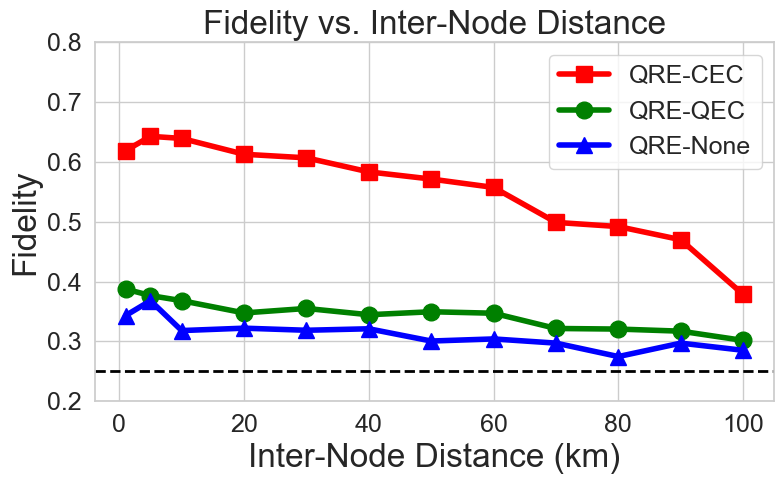

,elementary_link_km,correction_mode,mean_fidelity
0,1.0,cec,0.619000
1,1.0,none,0.343000
2,1.0,qec,0.387500
3,5.0,cec,0.643000
4,5.0,none,0.368000
5,5.0,qec,0.376500
6,10.0,cec,0.639500
7,10.0,none,0.318000
8,10.0,qec,0.368000
9,20.0,cec,0.613000


In [256]:
graph5_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph5_inter_node_distance_sweep")
graph5_df = load_runner_logs(graph5_log_dir)

# Average all completed runs at each inter-node distance and protocol setting.
graph5_summary = graph5_df.groupby(["elementary_link_km", "correction_mode"], as_index=False).agg(mean_fidelity=("fidelity", "mean")).sort_values(["elementary_link_km", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph5_summary[(graph5_summary["correction_mode"] == protocol) & (~graph5_summary["elementary_link_km"].isin([2.5, 7.5, 110,120]))]
    ax.plot(data["elementary_link_km"], data["mean_fidelity"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

# ax.set_xscale("log")
ax.set_xlabel("Inter-Node Distance (km)", fontsize=24)
ax.set_ylabel("Fidelity", fontsize=24)
ax.set_title("Fidelity vs. Inter-Node Distance", fontsize=24)
ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_ylim(0.2, 0.8)
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=18)

plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_inter_node_distance_5linktopology.png", dpi=300, bbox_inches="tight")
plt.show()

graph5_summary


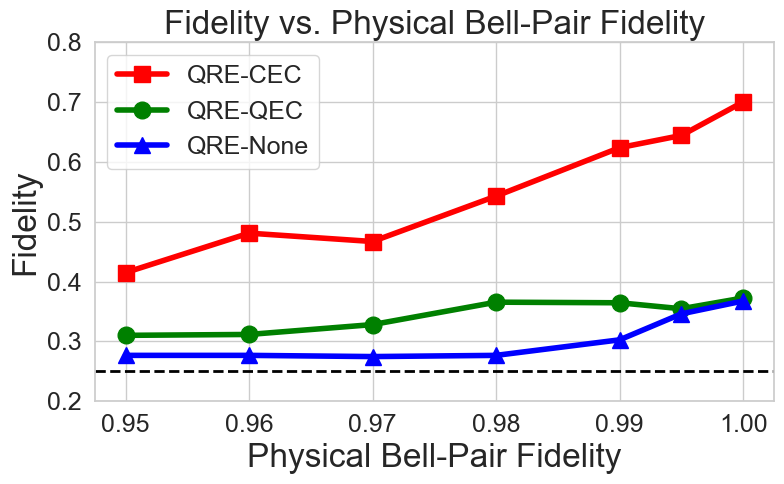

,physical_bell_pair_fidelity,correction_mode,mean_fidelity
0,0.950,cec,0.4150
1,0.950,none,0.2765
2,0.950,qec,0.3100
3,0.960,cec,0.4810
4,0.960,none,0.2765
5,0.960,qec,0.3115
6,0.970,cec,0.4670
7,0.970,none,0.2745
8,0.970,qec,0.3280
9,0.980,cec,0.5430


In [257]:
graph6_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph6_physical_bell_pair_fidelity_sweep")
graph6_df = load_runner_logs(graph6_log_dir)

# Average all completed runs at each physical Bell-pair fidelity and protocol setting.
graph6_summary = graph6_df.groupby(["physical_bell_pair_fidelity", "correction_mode"], as_index=False).agg(mean_fidelity=("fidelity", "mean")).sort_values(["physical_bell_pair_fidelity", "correction_mode"]).reset_index(drop=True)
colors = {"cec": "red", "none": "blue", "qec": "green"}
names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
markers = {"cec": "s", "none": "^", "qec": "o"}

plt.figure(figsize=(8, 5))
ax = plt.gca()

# Draw each protocol separately so the marker shapes stay fixed.
for protocol in ["cec", "qec", "none"]:
    data = graph6_summary[graph6_summary["correction_mode"] == protocol]
    ax.plot(data["physical_bell_pair_fidelity"], data["mean_fidelity"], color=colors[protocol], marker=markers[protocol], linewidth=4, markersize=12, label=names[protocol])

ax.set_xlabel("Physical Bell-Pair Fidelity", fontsize=24)
ax.set_ylabel("Fidelity", fontsize=24)
ax.set_title("Fidelity vs. Physical Bell-Pair Fidelity", fontsize=24)
ax.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
ax.set_ylim(0.2, 0.8)
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
ax.tick_params(axis="both", labelsize=18)
ax.legend(fontsize=18)

plt.tight_layout()
plt.savefig(output_dir / "fidelity_vs_physical_bell_pair_fidelity.png", dpi=300, bbox_inches="tight")
plt.show()

graph6_summary
